In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip "/content/iitm-dl18-pa1.zip"

Archive:  /content/iitm-dl18-pa1.zip
  inflating: sample_sub.csv          
  inflating: test.csv                
  inflating: train.csv               
  inflating: val.csv                 


In [3]:
import pandas as pd
import numpy as np

train_data = pd.read_csv("/content/train.csv")

test_data  = pd.read_csv("/content/test.csv")

val_data  = pd.read_csv ("/content/val.csv")

print("train Data"  , train_data.shape)
print("test Data"   , test_data.shape)
print("val Data"    , val_data.shape)



train Data (55000, 786)
test Data (10000, 785)
val Data (5000, 786)


In [4]:
train_data.head()



,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test_data.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat774,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783
0,0,0,0,0,0,0,0,1,1,2,...,2,0,0,60,36,24,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,123,97,0,0
2,2,0,0,0,0,0,0,0,0,0,...,2,1,0,0,115,150,47,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,144,0,0,0,0,0,0,0,0,0


In [6]:
val_data.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,55000,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,55001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,55002,0,0,0,0,0,0,0,0,0,...,176,195,144,0,0,0,0,0,0,0
3,55003,0,0,0,0,0,0,0,6,88,...,0,0,71,123,88,20,0,0,0,6
4,55004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [7]:
train_data.columns

Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat775', 'feat776', 'feat777', 'feat778', 'feat779', 'feat780',
       'feat781', 'feat782', 'feat783', 'label'],
      dtype='object', length=786)

In [8]:
val_data.columns


Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat775', 'feat776', 'feat777', 'feat778', 'feat779', 'feat780',
       'feat781', 'feat782', 'feat783', 'label'],
      dtype='object', length=786)

In [9]:
test_data.columns

Index(['id', 'feat0', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8',
       ...
       'feat774', 'feat775', 'feat776', 'feat777', 'feat778', 'feat779',
       'feat780', 'feat781', 'feat782', 'feat783'],
      dtype='object', length=785)

In [10]:



x_train = train_data.drop(["label","id"] , axis = 1 )
y_train = train_data["label"]

x_val = val_data.drop(["id" ,"label"] , axis = 1)
y_val = val_data["label"]
print(x_train)

       feat0  feat1  feat2  feat3  feat4  feat5  feat6  feat7  feat8  feat9  \
0          0      0      0      0      0      0      0      0      0      0   
1          0      0      0      0      0      1      0      0      0      0   
2          0      0      0      0      0      0      0      0      0     22   
3          0      0      0      0      0      0      0      0     33     96   
4          0      0      0      0      0      0      0      0      0      0   
...      ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
54995      0      0      0      0      0      0      0      0      0      0   
54996      0      0      0      0      0      0      0      0      0      0   
54997      0      0      0      0      0      0      0      0      0      0   
54998      0      0      0      0      0      0      0      0      0      0   
54999      0      0      0      0      0      1      1      0      0      0   

       ...  feat774  feat775  feat776  feat777  fea

In [11]:
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test =  test_data/255.0

print(x_train)





       feat0  feat1  feat2  feat3  feat4     feat5     feat6  feat7     feat8  \
0        0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
1        0.0    0.0    0.0    0.0    0.0  0.003922  0.000000    0.0  0.000000   
2        0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
3        0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.129412   
4        0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
...      ...    ...    ...    ...    ...       ...       ...    ...       ...   
54995    0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
54996    0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
54997    0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
54998    0.0    0.0    0.0    0.0    0.0  0.000000  0.000000    0.0  0.000000   
54999    0.0    0.0    0.0    0.0    0.0  0.003922  0.003922    0.0  0.000000   

          feat9  ...   feat

In [12]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input

In [ ]:
model= Sequential()
model.add (Dense (300, activation= "tanh" , input_shape= (784,)))
model.add (Dense (300, activation= "tanh"))
model.add (Dense (10, activation= "softmax"))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,810 (1.25 MB)

 Trainable params: 328,810 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile (optimizer="adam" , loss = "sparse_categorical_crossentropy" , metrics = ["accuracy"])

In [ ]:
history = model.fit(x_train, y_train,validation_data=(x_val, y_val),epochs=20,batch_size=20)

Epoch 1/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.7875 - loss: 0.5902 - val_accuracy: 0.8522 - val_loss: 0.4246
Epoch 2/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8601 - loss: 0.3806 - val_accuracy: 0.8518 - val_loss: 0.4057
Epoch 3/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8699 - loss: 0.3488 - val_accuracy: 0.8678 - val_loss: 0.3530
Epoch 4/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8817 - loss: 0.3192 - val_accuracy: 0.8730 - val_loss: 0.3510
Epoch 5/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8830 - loss: 0.3114 - val_accuracy: 0.8726 - val_loss: 0.3630
Epoch 6/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8873 - loss: 0.2999 - val_accuracy: 0.8722 - val_loss: 0.3443
Epoch 7/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8907 - loss: 0.2931 - val_accuracy: 0.8716 - val_loss: 0.3481
Epoch 8/20
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8971 - loss: 

In [ ]:
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

0.90787273645401
0.8776000142097473


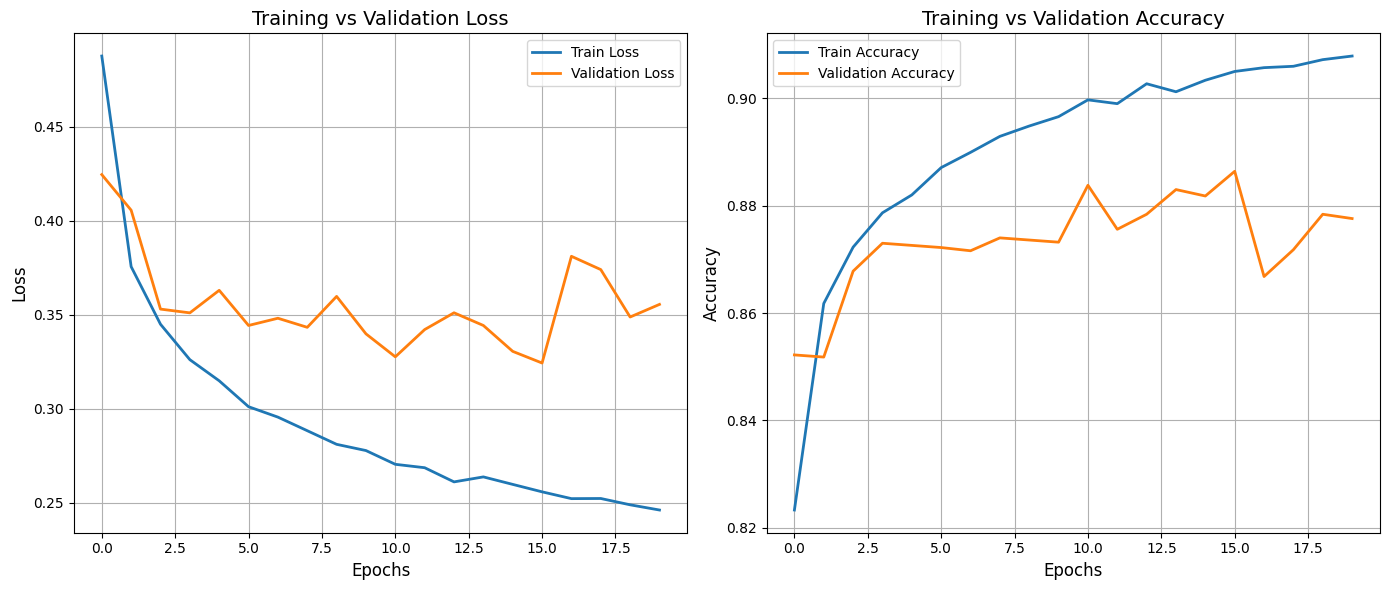

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# -------- Loss Plot --------
plt.subplot(1,2,1)
plt.plot(history.history['loss'], linewidth=2)
plt.plot(history.history['val_loss'], linewidth=2)
plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)


# -------- Accuracy Plot --------
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], linewidth=2)
plt.plot(history.history['val_accuracy'], linewidth=2)
plt.title("Training vs Validation Accuracy", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# experiment

In [ ]:
model_50 = Sequential()
model_50.add(Input(shape=(784,)))
model_50.add(Dense(50, activation="sigmoid"))
model_50.add(Dense(10, activation="softmax"))

model_50.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_50 = model_50.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7447 - loss: 0.8213 - val_accuracy: 0.8460 - val_loss: 0.4189
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8537 - loss: 0.4120 - val_accuracy: 0.8648 - val_loss: 0.3697
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8684 - loss: 0.3698 - val_accuracy: 0.8640 - val_loss: 0.3665
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8766 - loss: 0.3438 - val_accuracy: 0.8710 - val_loss: 0.3493
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8836 - loss: 0.3228 - val_accuracy: 0.8796 - val_loss: 0.3405
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8874 - loss: 0.3104 - val_accuracy: 0.8788 - val_loss: 0.3413
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8915 - loss: 0.3036 - val_accuracy: 0.8842 - val_loss: 0.3262
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8920 - loss: 0.292

In [ ]:

model_100 = Sequential()
model_100.add(Input(shape=(784,)))
model_100.add(Dense(100, activation="sigmoid"))
model_100.add(Dense(10, activation="softmax"))

model_100.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_100 = model_100.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7598 - loss: 0.7337 - val_accuracy: 0.8506 - val_loss: 0.4054
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8552 - loss: 0.4009 - val_accuracy: 0.8620 - val_loss: 0.3706
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8687 - loss: 0.3578 - val_accuracy: 0.8748 - val_loss: 0.3450
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8810 - loss: 0.3300 - val_accuracy: 0.8720 - val_loss: 0.3430
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8878 - loss: 0.3122 - val_accuracy: 0.8688 - val_loss: 0.3551
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8919 - loss: 0.2934 - val_accuracy: 0.8820 - val_loss: 0.3190
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8973 - loss: 0.2811 - val_accuracy: 0.8814 - val_loss: 0.3266
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9019 - loss: 0

In [ ]:
model_200 = Sequential()
model_200.add(Input(shape=(784,)))
model_200.add(Dense(200, activation="sigmoid"))
model_200.add(Dense(10, activation="softmax"))

model_200.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_200 = model_200.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.7736 - loss: 0.6693 - val_accuracy: 0.8540 - val_loss: 0.3942
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8607 - loss: 0.3873 - val_accuracy: 0.8664 - val_loss: 0.3579
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8742 - loss: 0.3461 - val_accuracy: 0.8728 - val_loss: 0.3433
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8829 - loss: 0.3166 - val_accuracy: 0.8794 - val_loss: 0.3246
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8919 - loss: 0.2956 - val_accuracy: 0.8806 - val_loss: 0.3245
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8965 - loss: 0.2780 - val_accuracy: 0.8790 - val_loss: 0.3173
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9024 - loss: 0.2615 - val_accuracy: 0.8836 - val_loss: 0.3207
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9075 - loss: 0

In [ ]:
model_300 = Sequential()
model_300.add(Input(shape=(784,)))
model_300.add(Dense(300, activation="sigmoid"))
model_300.add(Dense(10, activation="softmax"))

model_300.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_300 = model_300.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.7745 - loss: 0.6523 - val_accuracy: 0.8540 - val_loss: 0.3911
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8571 - loss: 0.3913 - val_accuracy: 0.8652 - val_loss: 0.3624
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8730 - loss: 0.3510 - val_accuracy: 0.8766 - val_loss: 0.3342
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8830 - loss: 0.3146 - val_accuracy: 0.8760 - val_loss: 0.3253
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8920 - loss: 0.2936 - val_accuracy: 0.8806 - val_loss: 0.3181
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8984 - loss: 0.2718 - val_accuracy: 0.8866 - val_loss: 0.3066
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9037 - loss: 0.2579 - val_accuracy: 0.8778 - val_loss: 0.3319
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.9076 - loss: 0

In [ ]:
print("model_50")
model_50.summary()


print("model_100")
model_100.summary()


print("model_200")
model_200.summary()


print("model_300")
model_300.summary()


model_50


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,282 (465.95 KB)

 Trainable params: 39,760 (155.31 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,532 (2.73 MB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 477,022 (1.82 MB)

In [ ]:
print("Final Accuracies:\n")

print("50 neurons  :",
      "Train =", history_50.history['accuracy'][-1],
      "| Val =", history_50.history['val_accuracy'][-1])

print("100 neurons :",
      "Train =", history_100.history['accuracy'][-1],
      "| Val =", history_100.history['val_accuracy'][-1])

print("200 neurons :",
      "Train =", history_200.history['accuracy'][-1],
      "| Val =", history_200.history['val_accuracy'][-1])

print("300 neurons :",
      "Train =", history_300.history['accuracy'][-1],
      "| Val =", history_300.history['val_accuracy'][-1])

Final Accuracies:

50 neurons  : Train = 0.932381808757782 | Val = 0.8845999836921692
100 neurons : Train = 0.947490930557251 | Val = 0.88919997215271
200 neurons : Train = 0.9571818113327026 | Val = 0.8884000182151794
300 neurons : Train = 0.9605273008346558 | Val = 0.8903999924659729


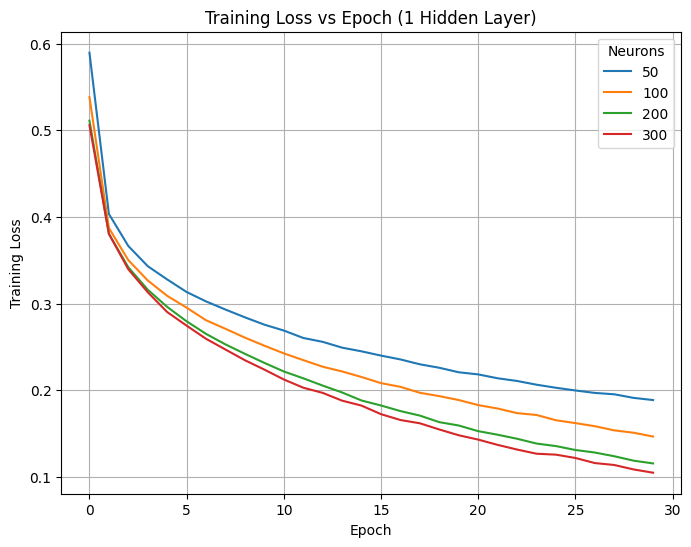

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_50.history['loss'], label='50')
plt.plot(history_100.history['loss'], label='100')
plt.plot(history_200.history['loss'], label='200')
plt.plot(history_300.history['loss'], label='300')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (1 Hidden Layer)")
plt.legend(title="Neurons")
plt.grid(True)
plt.show()

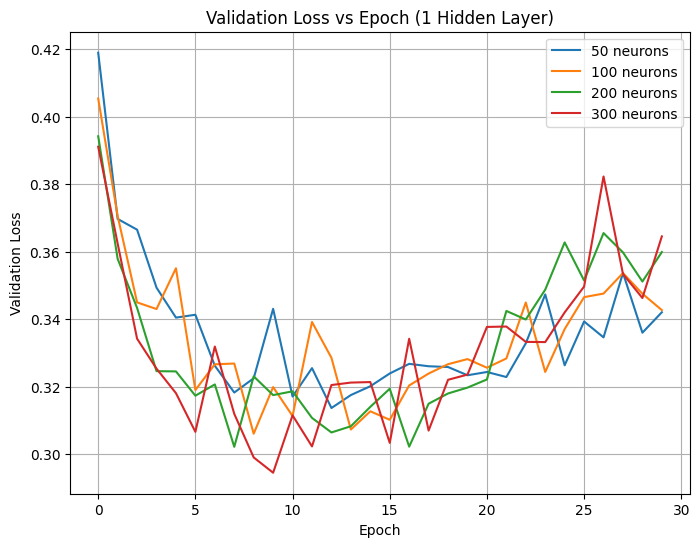

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_50.history['val_loss'], label='50 neurons')
plt.plot(history_100.history['val_loss'], label='100 neurons')
plt.plot(history_200.history['val_loss'], label='200 neurons')
plt.plot(history_300.history['val_loss'], label='300 neurons')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (1 Hidden Layer)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_50_50 = Sequential()
model_50_50.add(Input(shape=(784,)))
model_50_50.add(Dense(50, activation="sigmoid"))
model_50_50.add(Dense(50, activation="sigmoid"))
model_50_50.add(Dense(10, activation="softmax"))

model_50_50.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_50_50 = model_50_50.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.6812 - loss: 1.0185 - val_accuracy: 0.8444 - val_loss: 0.4236
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8510 - loss: 0.4112 - val_accuracy: 0.8556 - val_loss: 0.3849
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8694 - loss: 0.3616 - val_accuracy: 0.8610 - val_loss: 0.3707
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8786 - loss: 0.3390 - val_accuracy: 0.8732 - val_loss: 0.3468
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8852 - loss: 0.3206 - val_accuracy: 0.8674 - val_loss: 0.3556
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8874 - loss: 0.3087 - val_accuracy: 0.8780 - val_loss: 0.3285
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8911 - loss: 0.2997 - val_accuracy: 0.8764 - val_loss: 0.3438
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8942 - loss: 0.2

In [ ]:
model_100_100 = Sequential()
model_100_100.add(Input(shape=(784,)))
model_100_100.add(Dense(100, activation="sigmoid"))
model_100_100.add(Dense(100, activation="sigmoid"))
model_100_100.add(Dense(10, activation="softmax"))

model_100_100.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_100_100 = model_100_100.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7233 - loss: 0.8518 - val_accuracy: 0.8556 - val_loss: 0.3912
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8592 - loss: 0.3933 - val_accuracy: 0.8698 - val_loss: 0.3631
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8710 - loss: 0.3566 - val_accuracy: 0.8734 - val_loss: 0.3495
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.8838 - loss: 0.3232 - val_accuracy: 0.8714 - val_loss: 0.3486
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8876 - loss: 0.3089 - val_accuracy: 0.8808 - val_loss: 0.3246
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8911 - loss: 0.2971 - val_accuracy: 0.8836 - val_loss: 0.3238
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8957 - loss: 0.2800 - val_accuracy: 0.8754 - val_loss: 0.3378
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8973 - loss: 0

In [ ]:
model_200_200 = Sequential()
model_200_200.add(Input(shape=(784,)))
model_200_200.add(Dense(200, activation="sigmoid"))
model_200_200.add(Dense(200, activation="sigmoid"))
model_200_200.add(Dense(10, activation="softmax"))

model_200_200.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_200_200 = model_200_200.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.7415 - loss: 0.7488 - val_accuracy: 0.8528 - val_loss: 0.3948
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8574 - loss: 0.3962 - val_accuracy: 0.8564 - val_loss: 0.3870
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8733 - loss: 0.3487 - val_accuracy: 0.8658 - val_loss: 0.3730
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8810 - loss: 0.3227 - val_accuracy: 0.8798 - val_loss: 0.3223
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8896 - loss: 0.2945 - val_accuracy: 0.8782 - val_loss: 0.3383
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8963 - loss: 0.2778 - val_accuracy: 0.8862 - val_loss: 0.3099
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9025 - loss: 0.2614 - val_accuracy: 0.8846 - val_loss: 0.3256
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9050 - loss: 0

In [ ]:
model_300_300 = Sequential()
model_300_300.add(Input(shape=(784,)))
model_300_300.add(Dense(300, activation="sigmoid"))
model_300_300.add(Dense(300, activation="sigmoid"))
model_300_300.add(Dense(10, activation="softmax"))

model_300_300.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_300_300 = model_300_300.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.7515 - loss: 0.7064 - val_accuracy: 0.8492 - val_loss: 0.4032
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.8582 - loss: 0.3881 - val_accuracy: 0.8702 - val_loss: 0.3524
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8765 - loss: 0.3392 - val_accuracy: 0.8778 - val_loss: 0.3296
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8861 - loss: 0.3094 - val_accuracy: 0.8802 - val_loss: 0.3184
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8927 - loss: 0.2898 - val_accuracy: 0.8816 - val_loss: 0.3175
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8984 - loss: 0.2689 - val_accuracy: 0.8830 - val_loss: 0.3170
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.9032 - loss: 0.2566 - val_accuracy: 0.8864 - val_loss: 0.3169
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9085 - loss: 0

In [ ]:
print("Final Accuracies:\n")

print("50,50   : Train =", history_50_50.history['accuracy'][-1], "| Val =", history_50_50.history['val_accuracy'][-1])
print("100,100 : Train =", history_100_100.history['accuracy'][-1], "| Val =", history_100_100.history['val_accuracy'][-1])
print("200,200 : Train =", history_200_200.history['accuracy'][-1], "| Val =", history_200_200.history['val_accuracy'][-1])
print("300,300 : Train =", history_300_300.history['accuracy'][-1], "| Val =", history_300_300.history['val_accuracy'][-1])

Final Accuracies:

50,50   : Train = 0.9303091168403625 | Val = 0.8809999823570251
100,100 : Train = 0.9447818398475647 | Val = 0.8871999979019165
200,200 : Train = 0.9574727416038513 | Val = 0.8925999999046326
300,300 : Train = 0.9611091017723083 | Val = 0.8920000195503235


In [ ]:
print("\nFinal Accuracies (2 Hidden Layers):\n")

print("50,50   : Train =", history_50_50.history['accuracy'][-1],
      "| Val =", history_50_50.history['val_accuracy'][-1])

print("100,100 : Train =", history_100_100.history['accuracy'][-1],
      "| Val =", history_100_100.history['val_accuracy'][-1])

print("200,200 : Train =", history_200_200.history['accuracy'][-1],
      "| Val =", history_200_200.history['val_accuracy'][-1])

print("300,300 : Train =", history_300_300.history['accuracy'][-1],
      "| Val =", history_300_300.history['val_accuracy'][-1])


Final Accuracies (2 Hidden Layers):

50,50   : Train = 0.9303091168403625 | Val = 0.8809999823570251
100,100 : Train = 0.9447818398475647 | Val = 0.8871999979019165
200,200 : Train = 0.9574727416038513 | Val = 0.8925999999046326
300,300 : Train = 0.9611091017723083 | Val = 0.8920000195503235


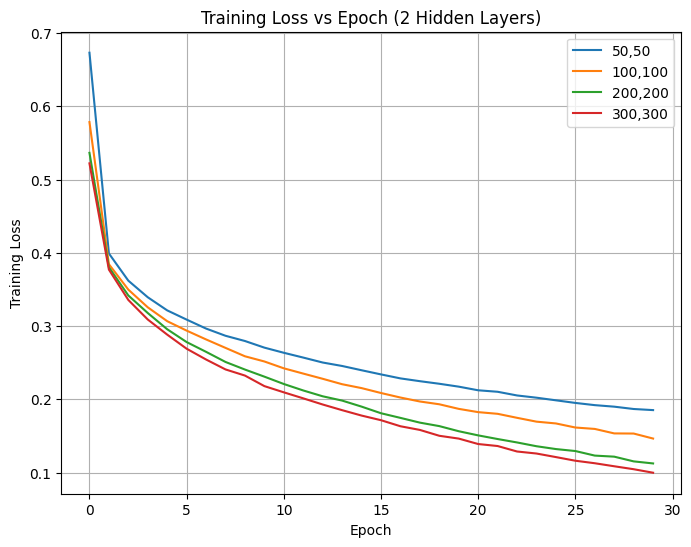

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_50_50.history['loss'], label='50,50')
plt.plot(history_100_100.history['loss'], label='100,100')
plt.plot(history_200_200.history['loss'], label='200,200')
plt.plot(history_300_300.history['loss'], label='300,300')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (2 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

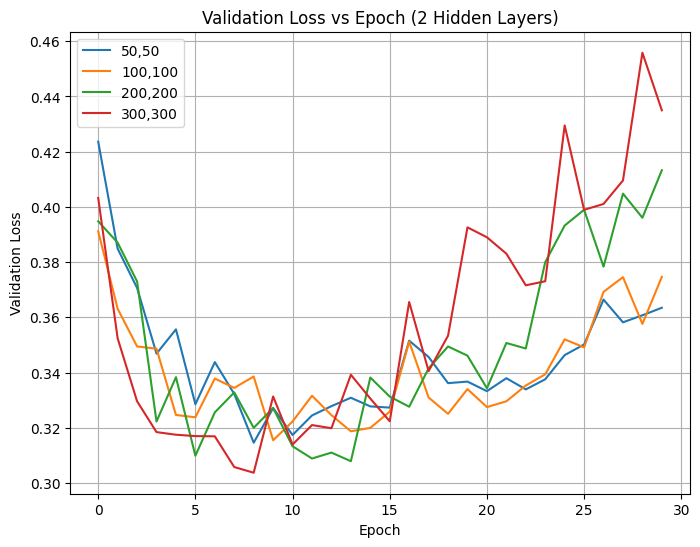

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_50_50.history['val_loss'], label='50,50')
plt.plot(history_100_100.history['val_loss'], label='100,100')
plt.plot(history_200_200.history['val_loss'], label='200,200')
plt.plot(history_300_300.history['val_loss'], label='300,300')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (2 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_50_50_50 = Sequential()
model_50_50_50.add(Input(shape=(784,)))
model_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50.add(Dense(10, activation="softmax"))

model_50_50_50.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_50_50_50 = model_50_50_50.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5754 - loss: 1.2288 - val_accuracy: 0.8422 - val_loss: 0.4478
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8475 - loss: 0.4328 - val_accuracy: 0.8542 - val_loss: 0.3938
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8685 - loss: 0.3689 - val_accuracy: 0.8660 - val_loss: 0.3641
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8775 - loss: 0.3418 - val_accuracy: 0.8736 - val_loss: 0.3506
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8849 - loss: 0.3214 - val_accuracy: 0.8594 - val_loss: 0.3699
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8896 - loss: 0.3070 - val_accuracy: 0.8748 - val_loss: 0.3375
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8911 - loss: 0.2987 - val_accuracy: 0.8740 - val_loss: 0.3418
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8918 - loss: 0.2913 

In [ ]:
model_100_100_100 = Sequential()
model_100_100_100.add(Input(shape=(784,)))
model_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100.add(Dense(10, activation="softmax"))

model_100_100_100.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_100_100_100 = model_100_100_100.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6457 - loss: 0.9878 - val_accuracy: 0.8450 - val_loss: 0.4208
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8533 - loss: 0.4094 - val_accuracy: 0.8620 - val_loss: 0.3669
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8726 - loss: 0.3565 - val_accuracy: 0.8686 - val_loss: 0.3544
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8790 - loss: 0.3344 - val_accuracy: 0.8786 - val_loss: 0.3355
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8885 - loss: 0.3099 - val_accuracy: 0.8732 - val_loss: 0.3538
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8924 - loss: 0.2979 - val_accuracy: 0.8820 - val_loss: 0.3324
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8978 - loss: 0.2787 - val_accuracy: 0.8816 - val_loss: 0.3277
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8991 - loss: 0.2773 -

In [ ]:
model_200_200_200 = Sequential()
model_200_200_200.add(Input(shape=(784,)))
model_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200.add(Dense(10, activation="softmax"))

model_200_200_200.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_200_200_200 = model_200_200_200.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6869 - loss: 0.8460 - val_accuracy: 0.8186 - val_loss: 0.4742
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8561 - loss: 0.3970 - val_accuracy: 0.8622 - val_loss: 0.3732
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8708 - loss: 0.3502 - val_accuracy: 0.8660 - val_loss: 0.3597
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8815 - loss: 0.3241 - val_accuracy: 0.8618 - val_loss: 0.3554
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8873 - loss: 0.3086 - val_accuracy: 0.8822 - val_loss: 0.3309
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8941 - loss: 0.2934 - val_accuracy: 0.8832 - val_loss: 0.3151
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8969 - loss: 0.2782 - val_accuracy: 0.8822 - val_loss: 0.3147
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9002 - loss: 0.2658 

In [ ]:
model_300_300_300 = Sequential()
model_300_300_300.add(Input(shape=(784,)))
model_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300.add(Dense(10, activation="softmax"))

model_300_300_300.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_300_300_300 = model_300_300_300.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7033 - loss: 0.7965 - val_accuracy: 0.8528 - val_loss: 0.4015
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8544 - loss: 0.4022 - val_accuracy: 0.8670 - val_loss: 0.3693
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8747 - loss: 0.3479 - val_accuracy: 0.8618 - val_loss: 0.3667
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8822 - loss: 0.3173 - val_accuracy: 0.8790 - val_loss: 0.3157
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8865 - loss: 0.3010 - val_accuracy: 0.8760 - val_loss: 0.3237
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8935 - loss: 0.2852 - val_accuracy: 0.8788 - val_loss: 0.3144
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8996 - loss: 0.2681 - val_accuracy: 0.8924 - val_loss: 0.3017
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9052 - loss: 0.2487 -

In [ ]:
print("\nModel 50,50,50 Summary")
model_50_50_50.summary()

print("\nModel 100,100,100 Summary")
model_100_100_100.summary()

print("\nModel 200,200,200 Summary")
model_200_200_200.summary()

print("\nModel 300,300,300 Summary")
model_300_300_300.summary()


Model 50,50,50 Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,582 (525.71 KB)

 Trainable params: 44,860 (175.23 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,257,332 (4.80 MB)

 Trainable params: 419,110 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 838,222 (3.20 MB)

In [ ]:
print("\nFinal Accuracies (3 Hidden Layers):\n")

print("50,50,50     : Train =", history_50_50_50.history['accuracy'][-1],
      "| Val =", history_50_50_50.history['val_accuracy'][-1])

print("100,100,100  : Train =", history_100_100_100.history['accuracy'][-1],
      "| Val =", history_100_100_100.history['val_accuracy'][-1])

print("200,200,200  : Train =", history_200_200_200.history['accuracy'][-1],
      "| Val =", history_200_200_200.history['val_accuracy'][-1])

print("300,300,300  : Train =", history_300_300_300.history['accuracy'][-1],
      "| Val =", history_300_300_300.history['val_accuracy'][-1])


Final Accuracies (3 Hidden Layers):

50,50,50     : Train = 0.9319272637367249 | Val = 0.8804000020027161
100,100,100  : Train = 0.94276362657547 | Val = 0.8907999992370605
200,200,200  : Train = 0.9533454775810242 | Val = 0.8899999856948853
300,300,300  : Train = 0.95494544506073 | Val = 0.8898000121116638


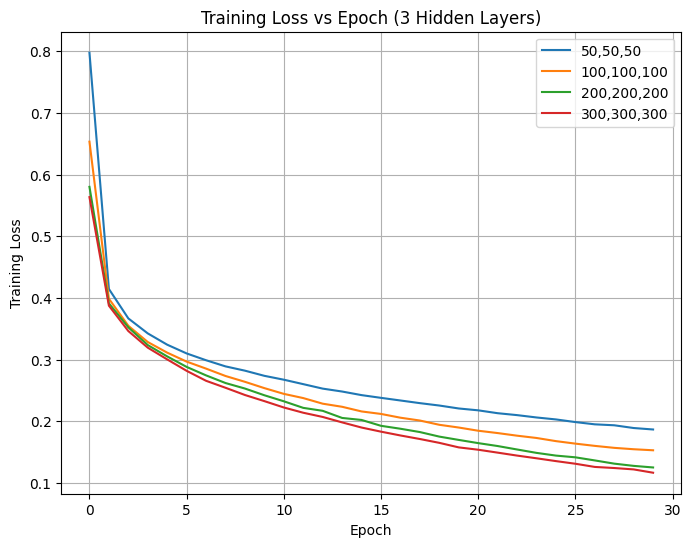

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_50_50_50.history['loss'], label='50,50,50')
plt.plot(history_100_100_100.history['loss'], label='100,100,100')
plt.plot(history_200_200_200.history['loss'], label='200,200,200')
plt.plot(history_300_300_300.history['loss'], label='300,300,300')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (3 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

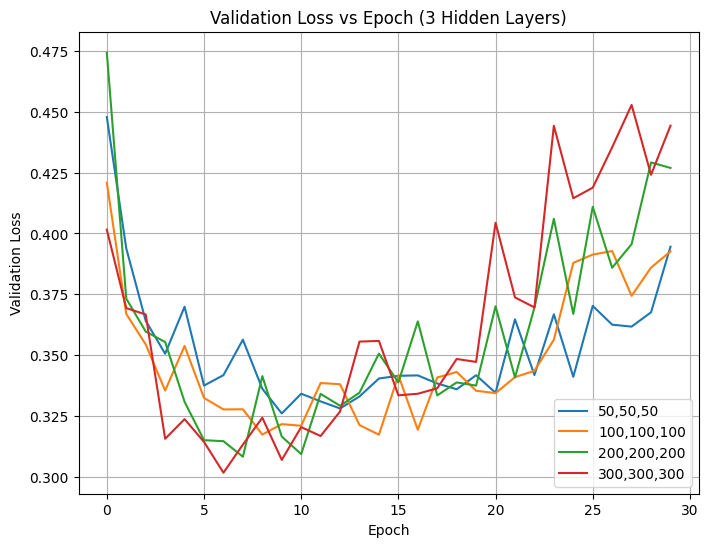

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_50_50_50.history['val_loss'], label='50,50,50')
plt.plot(history_100_100_100.history['val_loss'], label='100,100,100')
plt.plot(history_200_200_200.history['val_loss'], label='200,200,200')
plt.plot(history_300_300_300.history['val_loss'], label='300,300,300')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (3 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 4

In [ ]:
model_50_50_50_50 = Sequential()
model_50_50_50_50.add(Input(shape=(784,)))
model_50_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50_50.add(Dense(50, activation="sigmoid"))
model_50_50_50_50.add(Dense(10, activation="softmax"))

model_50_50_50_50.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_50_50_50_50 = model_50_50_50_50.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.4399 - loss: 1.3942 - val_accuracy: 0.7634 - val_loss: 0.6546
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7805 - loss: 0.5957 - val_accuracy: 0.8116 - val_loss: 0.4859
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8283 - loss: 0.4652 - val_accuracy: 0.8568 - val_loss: 0.4100
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8589 - loss: 0.4013 - val_accuracy: 0.8558 - val_loss: 0.4044
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8699 - loss: 0.3713 - val_accuracy: 0.8642 - val_loss: 0.3918
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8779 - loss: 0.3491 - val_accuracy: 0.8628 - val_loss: 0.3812
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8789 - loss: 0.3396 - val_accuracy: 0.8592 - val_loss: 0.3875
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8846 - loss: 0.3227 -

In [ ]:
model_100_100_100_100 = Sequential()
model_100_100_100_100.add(Input(shape=(784,)))
model_100_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100_100.add(Dense(100, activation="sigmoid"))
model_100_100_100_100.add(Dense(10, activation="softmax"))

model_100_100_100_100.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_100_100_100_100 = model_100_100_100_100.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4924 - loss: 1.2525 - val_accuracy: 0.8318 - val_loss: 0.4728
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8429 - loss: 0.4476 - val_accuracy: 0.8518 - val_loss: 0.4176
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8629 - loss: 0.3906 - val_accuracy: 0.8552 - val_loss: 0.3902
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8715 - loss: 0.3590 - val_accuracy: 0.8724 - val_loss: 0.3439
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8797 - loss: 0.3369 - val_accuracy: 0.8744 - val_loss: 0.3403
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8892 - loss: 0.3122 - val_accuracy: 0.8672 - val_loss: 0.3716
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8909 - loss: 0.3001 - val_accuracy: 0.8780 - val_loss: 0.3323
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8963 - loss: 0.2859 -

In [ ]:
model_200_200_200_200 = Sequential()
model_200_200_200_200.add(Input(shape=(784,)))
model_200_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200_200.add(Dense(200, activation="sigmoid"))
model_200_200_200_200.add(Dense(10, activation="softmax"))

model_200_200_200_200.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_200_200_200_200 = model_200_200_200_200.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6159 - loss: 0.9913 - val_accuracy: 0.8290 - val_loss: 0.4684
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8449 - loss: 0.4398 - val_accuracy: 0.8480 - val_loss: 0.4245
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8667 - loss: 0.3686 - val_accuracy: 0.8568 - val_loss: 0.3926
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8758 - loss: 0.3374 - val_accuracy: 0.8596 - val_loss: 0.3762
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8822 - loss: 0.3211 - val_accuracy: 0.8486 - val_loss: 0.4167
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8911 - loss: 0.2993 - val_accuracy: 0.8808 - val_loss: 0.3283
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8944 - loss: 0.2835 - val_accuracy: 0.8652 - val_loss: 0.3578
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8977 - loss: 0.2750 -

In [ ]:
model_300_300_300_300 = Sequential()
model_300_300_300_300.add(Input(shape=(784,)))
model_300_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300_300.add(Dense(300, activation="sigmoid"))
model_300_300_300_300.add(Dense(10, activation="softmax"))

model_300_300_300_300.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_300_300_300_300 = model_300_300_300_300.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6304 - loss: 0.9377 - val_accuracy: 0.8426 - val_loss: 0.4352
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8474 - loss: 0.4275 - val_accuracy: 0.8686 - val_loss: 0.3634
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8667 - loss: 0.3689 - val_accuracy: 0.8688 - val_loss: 0.3590
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8753 - loss: 0.3448 - val_accuracy: 0.8772 - val_loss: 0.3381
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8837 - loss: 0.3197 - val_accuracy: 0.8822 - val_loss: 0.3303
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8908 - loss: 0.2972 - val_accuracy: 0.8792 - val_loss: 0.3503
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8954 - loss: 0.2783 - val_accuracy: 0.8816 - val_loss: 0.3152
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9006 - loss: 0.2678 -

In [ ]:

print("\nModel 50,50,50,50 Summary")
model_50_50_50_50.summary()

print("\nModel 100,100,100,100 Summary")
model_100_100_100_100.summary()

print("\nModel 200,200,200 ,200 Summary")
model_200_200_200_200.summary()

print("\nModel 300,300,300.300 Summary")
model_300_300_300_300.summary()


Model 50,50,50,50 Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,232 (555.60 KB)

 Trainable params: 47,410 (185.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,528,232 (5.83 MB)

 Trainable params: 509,410 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,018,822 (3.89 MB)

In [ ]:
print("\nFinal Accuracies (4 Hidden Layers):\n")

print("50x4   : Train =", history_50_50_50_50.history['accuracy'][-1],
      "| Val =", history_50_50_50_50.history['val_accuracy'][-1])

print("100x4  : Train =", history_100_100_100_100.history['accuracy'][-1],
      "| Val =", history_100_100_100_100.history['val_accuracy'][-1])

print("200x4  : Train =", history_200_200_200_200.history['accuracy'][-1],
      "| Val =", history_200_200_200_200.history['val_accuracy'][-1])

print("300x4  : Train =", history_300_300_300_300.history['accuracy'][-1],
      "| Val =", history_300_300_300_300.history['val_accuracy'][-1])


Final Accuracies (4 Hidden Layers):

50x4   : Train = 0.9243090748786926 | Val = 0.8822000026702881
100x4  : Train = 0.9377636313438416 | Val = 0.8866000175476074
200x4  : Train = 0.9477454423904419 | Val = 0.8920000195503235
300x4  : Train = 0.9479818344116211 | Val = 0.8970000147819519


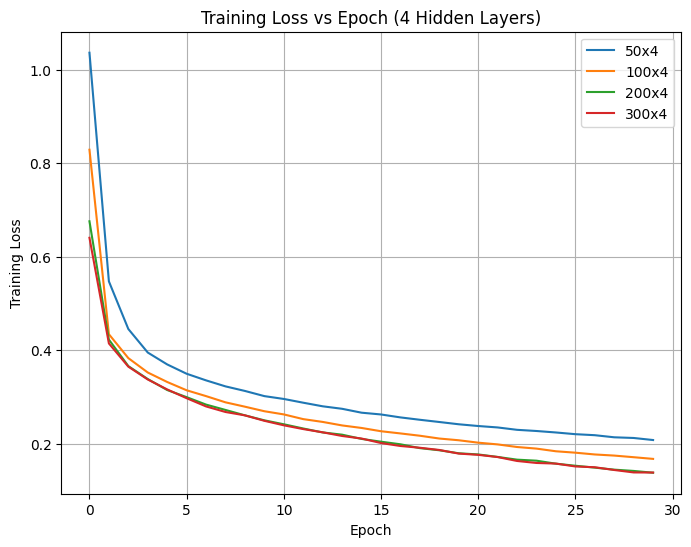

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

plt.plot(history_50_50_50_50.history['loss'], label='50x4')
plt.plot(history_100_100_100_100.history['loss'], label='100x4')
plt.plot(history_200_200_200_200.history['loss'], label='200x4')
plt.plot(history_300_300_300_300.history['loss'], label='300x4')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (4 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

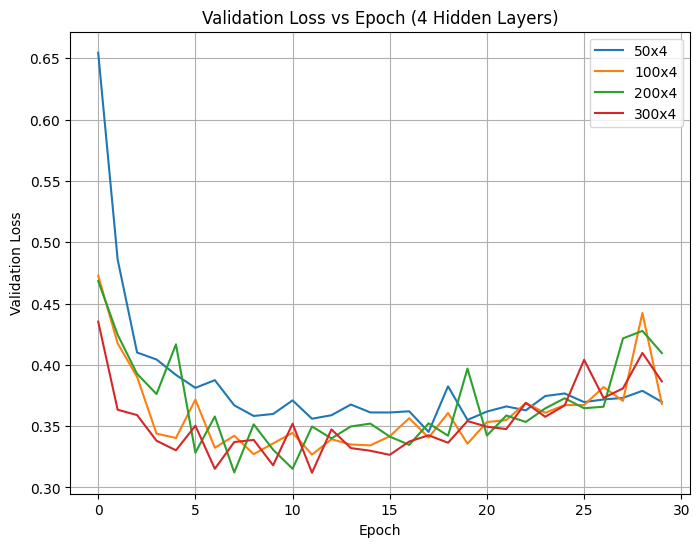

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_50_50_50_50.history['val_loss'], label='50x4')
plt.plot(history_100_100_100_100.history['val_loss'], label='100x4')
plt.plot(history_200_200_200_200.history['val_loss'], label='200x4')
plt.plot(history_300_300_300_300.history['val_loss'], label='300x4')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (4 Hidden Layers)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam
model_sgd = Sequential()
model_sgd.add(Input(shape= (784,)))
model_sgd.add(Dense(300 ,activation= "sigmoid"))
model_sgd.add(Dense(300,activation="sigmoid"))
model_sgd.add(Dense(300,activation= "sigmoid"))
model_sgd.add(Dense(10,activation="softmax"))

model_sgd.compile(optimizer=SGD(learning_rate=0.01),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

history_sgd = model_sgd.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=30,batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.1211 - loss: 2.3018 - val_accuracy: 0.2934 - val_loss: 2.1951
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3117 - loss: 2.0023 - val_accuracy: 0.5138 - val_loss: 1.4446
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.5502 - loss: 1.3266 - val_accuracy: 0.6102 - val_loss: 1.0493
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6215 - loss: 1.0207 - val_accuracy: 0.6690 - val_loss: 0.8939
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6626 - loss: 0.8906 - val_accuracy: 0.6848 - val_loss: 0.8102
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6925 - loss: 0.8015 - val_accuracy: 0.7400 - val_loss: 0.7409
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7267 - loss: 0.7314 - val_accuracy: 0.7504 - val_loss: 0.6780
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7490 - loss: 0.6792 -

In [ ]:
model_momentum = Sequential()
model_momentum.add(Input(shape=(784,)))
model_momentum.add(Dense(300, activation="sigmoid"))
model_momentum.add(Dense(300, activation="sigmoid"))
model_momentum.add(Dense(300, activation="sigmoid"))
model_momentum.add(Dense(10, activation="softmax"))

model_momentum.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_momentum = model_momentum.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.3722 - loss: 1.6490 - val_accuracy: 0.7572 - val_loss: 0.6506
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7683 - loss: 0.6273 - val_accuracy: 0.8176 - val_loss: 0.5009
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8171 - loss: 0.5090 - val_accuracy: 0.8318 - val_loss: 0.4599
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8348 - loss: 0.4648 - val_accuracy: 0.8400 - val_loss: 0.4253
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8408 - loss: 0.4365 - val_accuracy: 0.8480 - val_loss: 0.4120
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8510 - loss: 0.4177 - val_accuracy: 0.8302 - val_loss: 0.4556
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8570 - loss: 0.3940 - val_accuracy: 0.8604 - val_loss: 0.3845
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8611 - loss: 0.3793 -

In [ ]:
model_nag = Sequential()
model_nag.add(Input(shape=(784,)))
model_nag.add(Dense(300, activation="sigmoid"))
model_nag.add(Dense(300, activation="sigmoid"))
model_nag.add(Dense(300, activation="sigmoid"))
model_nag.add(Dense(10, activation="softmax"))

model_nag.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_nag = model_nag.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3806 - loss: 1.6181 - val_accuracy: 0.7570 - val_loss: 0.6673
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7726 - loss: 0.6070 - val_accuracy: 0.8020 - val_loss: 0.5369
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8183 - loss: 0.5108 - val_accuracy: 0.8334 - val_loss: 0.4525
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8369 - loss: 0.4562 - val_accuracy: 0.8348 - val_loss: 0.4573
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8451 - loss: 0.4295 - val_accuracy: 0.8526 - val_loss: 0.3978
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8547 - loss: 0.4018 - val_accuracy: 0.8586 - val_loss: 0.3839
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8560 - loss: 0.3956 - val_accuracy: 0.8598 - val_loss: 0.3931
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8654 - loss: 0.3733 - 

In [ ]:
model_adam = Sequential()
model_adam.add(Input(shape=(784,)))
model_adam.add(Dense(300, activation="sigmoid"))
model_adam.add(Dense(300, activation="sigmoid"))
model_adam.add(Dense(300, activation="sigmoid"))
model_adam.add(Dense(10, activation="softmax"))

model_adam.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_adam = model_adam.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6991 - loss: 0.8116 - val_accuracy: 0.8554 - val_loss: 0.3856
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8563 - loss: 0.3977 - val_accuracy: 0.8422 - val_loss: 0.4295
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8710 - loss: 0.3522 - val_accuracy: 0.8738 - val_loss: 0.3543
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8793 - loss: 0.3229 - val_accuracy: 0.8828 - val_loss: 0.3188
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8907 - loss: 0.2953 - val_accuracy: 0.8824 - val_loss: 0.3139
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8966 - loss: 0.2804 - val_accuracy: 0.8834 - val_loss: 0.3208
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9021 - loss: 0.2651 - val_accuracy: 0.8872 - val_loss: 0.3058
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9042 - loss: 0.2541 

In [ ]:
print("\nSGD Model Summary")
model_sgd.summary()

print("\nMomentum Model Summary")
model_momentum.summary()

print("\nNAG Model Summary")
model_nag.summary()

print("\nAdam Model Summary")
model_adam.summary()


SGD Model Summary


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,112 (1.60 MB)

 Trainable params: 419,110 (1.60 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,257,332 (4.80 MB)

 Trainable params: 419,110 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 838,222 (3.20 MB)

In [ ]:
print("\nFinal Accuracies (Optimizer Comparison):\n")

print("SGD      : Train =", history_sgd.history['accuracy'][-1], "| Val =", history_sgd.history['val_accuracy'][-1])
print("Momentum : Train =", history_momentum.history['accuracy'][-1], "| Val =", history_momentum.history['val_accuracy'][-1])
print("NAG      : Train =", history_nag.history['accuracy'][-1], "| Val =", history_nag.history['val_accuracy'][-1])
print("Adam     : Train =", history_adam.history['accuracy'][-1], "| Val =", history_adam.history['val_accuracy'][-1])


Final Accuracies (Optimizer Comparison):

SGD      : Train = 0.8515636324882507 | Val = 0.8479999899864197
Momentum : Train = 0.9084181785583496 | Val = 0.8826000094413757
NAG      : Train = 0.9135454297065735 | Val = 0.8873999714851379
Adam     : Train = 0.9557999968528748 | Val = 0.894599974155426


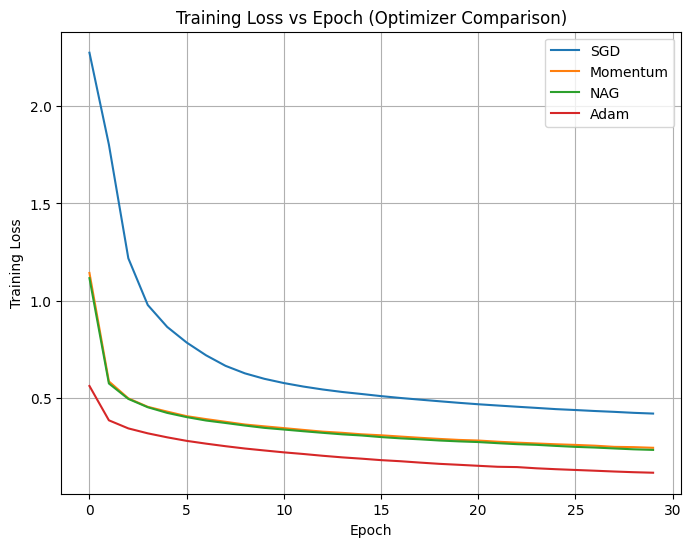

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_momentum.history['loss'], label='Momentum')
plt.plot(history_nag.history['loss'], label='NAG')
plt.plot(history_adam.history['loss'], label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (Optimizer Comparison)")
plt.legend()
plt.grid(True)
plt.show()

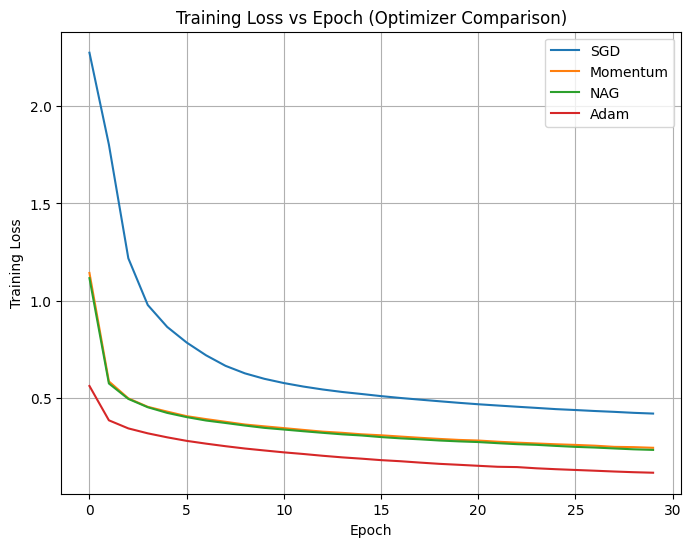

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_momentum.history['loss'], label='Momentum')
plt.plot(history_nag.history['loss'], label='NAG')
plt.plot(history_adam.history['loss'], label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (Optimizer Comparison)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Activation Function Comparison tanh and sigmoid

In [ ]:

model_sigmoid = Sequential()
model_sigmoid.add(Input(shape=(784,)))
model_sigmoid.add(Dense(100, activation="sigmoid"))
model_sigmoid.add(Dense(100, activation="sigmoid"))
model_sigmoid.add(Dense(10, activation="softmax"))

model_sigmoid.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_sigmoid = model_sigmoid.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7189 - loss: 0.8470 - val_accuracy: 0.8438 - val_loss: 0.4178
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8572 - loss: 0.3922 - val_accuracy: 0.8582 - val_loss: 0.3719
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8722 - loss: 0.3492 - val_accuracy: 0.8684 - val_loss: 0.3717
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8818 - loss: 0.3296 - val_accuracy: 0.8736 - val_loss: 0.3405
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8874 - loss: 0.3070 - val_accuracy: 0.8802 - val_loss: 0.3297
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8897 - loss: 0.2914 - val_accuracy: 0.8836 - val_loss: 0.3202
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8962 - loss: 0.2807 - val_accuracy: 0.8832 - val_loss: 0.3226
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9035 - loss: 0.2622 -

In [ ]:
model_tanh = Sequential()
model_tanh.add(Input(shape=(784,)))
model_tanh.add(Dense(100, activation="tanh"))
model_tanh.add(Dense(100, activation="tanh"))
model_tanh.add(Dense(10, activation="softmax"))

model_tanh.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_tanh = model_tanh.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7900 - loss: 0.5824 - val_accuracy: 0.8524 - val_loss: 0.3912
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8657 - loss: 0.3685 - val_accuracy: 0.8606 - val_loss: 0.3790
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8769 - loss: 0.3358 - val_accuracy: 0.8740 - val_loss: 0.3430
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8849 - loss: 0.3083 - val_accuracy: 0.8704 - val_loss: 0.3445
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8913 - loss: 0.2955 - val_accuracy: 0.8742 - val_loss: 0.3405
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8942 - loss: 0.2824 - val_accuracy: 0.8744 - val_loss: 0.3393
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9003 - loss: 0.2683 - val_accuracy: 0.8718 - val_loss: 0.3487
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9007 - loss: 0.2632 - 

In [ ]:
print("\nSigmoid Model Summary")
model_sigmoid.summary()

print("\nTanh Model Summary")
model_tanh.summary()


Sigmoid Model Summary


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,222 (700.09 KB)

In [ ]:
print("\nFinal Accuracies (Activation Comparison):\n")

print("Sigmoid : Train =", history_sigmoid.history['accuracy'][-1],
      "| Val =", history_sigmoid.history['val_accuracy'][-1])

print("Tanh    : Train =", history_tanh.history['accuracy'][-1],
      "| Val =", history_tanh.history['val_accuracy'][-1])


Final Accuracies (Activation Comparison):

Sigmoid : Train = 0.9465818405151367 | Val = 0.8953999876976013
Tanh    : Train = 0.9369999766349792 | Val = 0.8880000114440918


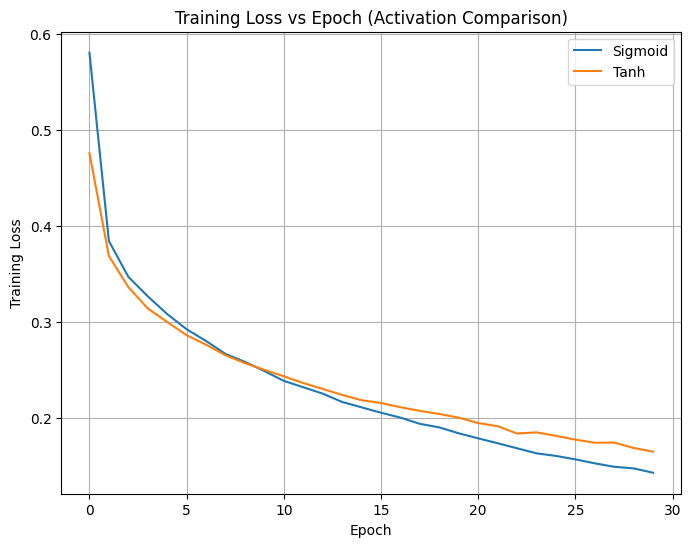

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_sigmoid.history['loss'], label='Sigmoid')
plt.plot(history_tanh.history['loss'], label='Tanh')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (Activation Comparison)")
plt.legend()
plt.grid(True)
plt.show()

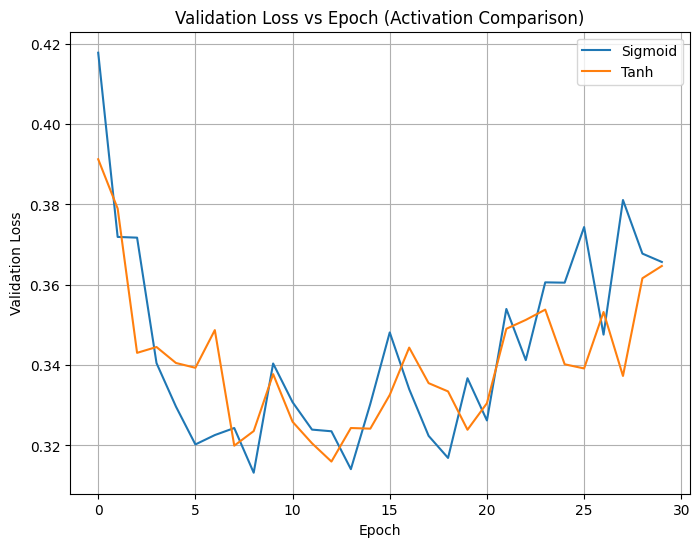

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(history_tanh.history['val_loss'], label='Tanh')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (Activation Comparison)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# loss function change karenge: Squared Error (MSE)  and  Cross Entropy

In [ ]:
model_ce = Sequential()
model_ce.add(Input(shape=(784,)))
model_ce.add(Dense(100, activation="sigmoid"))
model_ce.add(Dense(100, activation="sigmoid"))
model_ce.add(Dense(10, activation="softmax"))

model_ce.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_ce = model_ce.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7130 - loss: 0.8658 - val_accuracy: 0.8382 - val_loss: 0.4344
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8608 - loss: 0.3845 - val_accuracy: 0.8644 - val_loss: 0.3717
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8724 - loss: 0.3513 - val_accuracy: 0.8770 - val_loss: 0.3367
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8833 - loss: 0.3166 - val_accuracy: 0.8798 - val_loss: 0.3258
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8849 - loss: 0.3093 - val_accuracy: 0.8780 - val_loss: 0.3239
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8916 - loss: 0.2944 - val_accuracy: 0.8766 - val_loss: 0.3369
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8949 - loss: 0.2798 - val_accuracy: 0.8870 - val_loss: 0.3116
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9034 - loss: 0.2629 -

In [ ]:
model_mse = Sequential()
model_mse.add(Input(shape=(784,)))
model_mse.add(Dense(100, activation="sigmoid"))
model_mse.add(Dense(100, activation="sigmoid"))
model_mse.add(Dense(10, activation="softmax"))

model_mse.compile(optimizer="adam", loss="mse", metrics=["accuracy"])

history_mse = model_mse.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1099 - loss: 27.5548 - val_accuracy: 0.1096 - val_loss: 27.5422
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1031 - loss: 27.5593 - val_accuracy: 0.1010 - val_loss: 27.5422
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0990 - loss: 27.6970 - val_accuracy: 0.0996 - val_loss: 27.5422
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.0979 - loss: 27.7834 - val_accuracy: 0.1506 - val_loss: 27.5422
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0987 - loss: 27.8709 - val_accuracy: 0.0984 - val_loss: 27.5422
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.0952 - loss: 27.6299 - val_accuracy: 0.1036 - val_loss: 27.5422
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1013 - loss: 27.5776 - val_accuracy: 0.0736 - val_loss: 27.5422
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1011 - 

In [ ]:
print("\nCross Entropy Model Summary")
model_ce.summary()

print("\nMSE Model Summary")
model_mse.summary()


Cross Entropy Model Summary


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,222 (700.09 KB)

In [ ]:
print("\nFinal Accuracies (Loss Comparison):\n")

print("Cross Entropy : Train =", history_ce.history['accuracy'][-1],
      "| Val =", history_ce.history['val_accuracy'][-1])

print("MSE           : Train =", history_mse.history['accuracy'][-1],
      "| Val =", history_mse.history['val_accuracy'][-1])


Final Accuracies (Loss Comparison):

Cross Entropy : Train = 0.9463454484939575 | Val = 0.8895999789237976
MSE           : Train = 0.09790909290313721 | Val = 0.09960000216960907


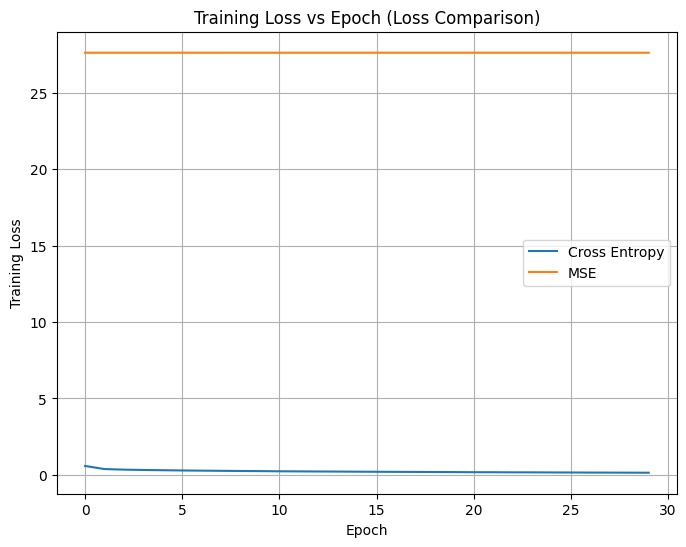

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_ce.history['loss'], label='Cross Entropy')
plt.plot(history_mse.history['loss'], label='MSE')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (Loss Comparison)")
plt.legend()
plt.grid(True)
plt.show()

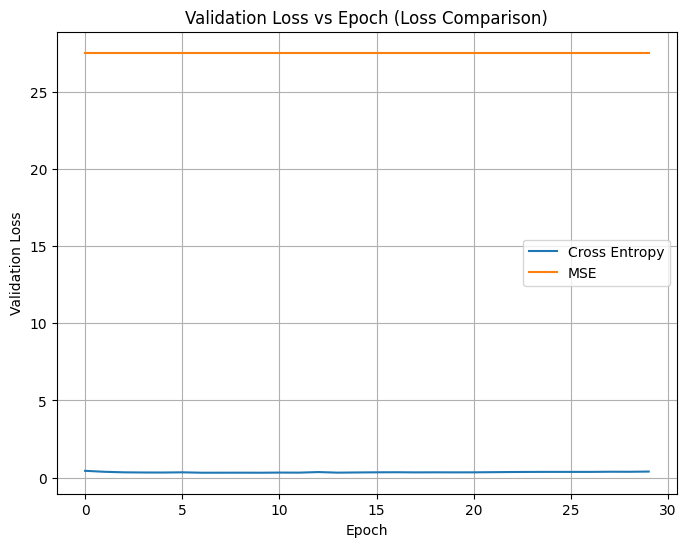

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_ce.history['val_loss'], label='Cross Entropy')
plt.plot(history_mse.history['val_loss'], label='MSE')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (Loss Comparison)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Batch Size Comparison 1,20 ,100,1000

In [ ]:
model_bs1 = Sequential()
model_bs1.add(Input(shape=(784,)))
model_bs1.add(Dense(100, activation="sigmoid"))
model_bs1.add(Dense(100, activation="sigmoid"))
model_bs1.add(Dense(10, activation="softmax"))

model_bs1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_bs1 = model_bs1.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=1)

Epoch 1/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 150s 3ms/step - accuracy: 0.7717 - loss: 0.6326 - val_accuracy: 0.8490 - val_loss: 0.4170
Epoch 2/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 152s 3ms/step - accuracy: 0.8533 - loss: 0.4021 - val_accuracy: 0.8490 - val_loss: 0.4029
Epoch 3/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 198s 3ms/step - accuracy: 0.8653 - loss: 0.3686 - val_accuracy: 0.8586 - val_loss: 0.4027
Epoch 4/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 152s 3ms/step - accuracy: 0.8669 - loss: 0.3574 - val_accuracy: 0.8692 - val_loss: 0.3771
Epoch 5/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 156s 3ms/step - accuracy: 0.8759 - loss: 0.3429 - val_accuracy: 0.8666 - val_loss: 0.3756
Epoch 6/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 147s 3ms/step - accuracy: 0.8762 - loss: 0.3337 - val_accuracy: 0.8756 - val_loss: 0.3696
Epoch 7/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 149s 3ms/step - accuracy: 0.8855 - loss: 0.3218 - val_accuracy: 0.8638 - val_loss: 0.4233
Epoch 8/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 155s 3ms/step - ac

In [ ]:
model_bs20 = Sequential()
model_bs20.add(Input(shape=(784,)))
model_bs20.add(Dense(100, activation="sigmoid"))
model_bs20.add(Dense(100, activation="sigmoid"))
model_bs20.add(Dense(10, activation="softmax"))

model_bs20.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_bs20 = model_bs20.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=20)

Epoch 1/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7152 - loss: 0.8599 - val_accuracy: 0.8544 - val_loss: 0.4005
Epoch 2/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8602 - loss: 0.3867 - val_accuracy: 0.8616 - val_loss: 0.3762
Epoch 3/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8708 - loss: 0.3559 - val_accuracy: 0.8716 - val_loss: 0.3465
Epoch 4/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8799 - loss: 0.3252 - val_accuracy: 0.8744 - val_loss: 0.3330
Epoch 5/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8879 - loss: 0.3062 - val_accuracy: 0.8816 - val_loss: 0.3236
Epoch 6/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8955 - loss: 0.2867 - val_accuracy: 0.8790 - val_loss: 0.3253
Epoch 7/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8988 - loss: 0.2757 - val_accuracy: 0.8782 - val_loss: 0.3193
Epoch 8/30
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9020 - loss: 0.2

In [ ]:
model_bs100 = Sequential()
model_bs100.add(Input(shape=(784,)))
model_bs100.add(Dense(100, activation="sigmoid"))
model_bs100.add(Dense(100, activation="sigmoid"))
model_bs100.add(Dense(10, activation="softmax"))

model_bs100.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_bs100 = model_bs100.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=100)

Epoch 1/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6075 - loss: 1.2557 - val_accuracy: 0.8252 - val_loss: 0.4943
Epoch 2/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8336 - loss: 0.4713 - val_accuracy: 0.8520 - val_loss: 0.3970
Epoch 3/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8576 - loss: 0.3970 - val_accuracy: 0.8620 - val_loss: 0.3693
Epoch 4/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8673 - loss: 0.3658 - val_accuracy: 0.8712 - val_loss: 0.3537
Epoch 5/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8747 - loss: 0.3452 - val_accuracy: 0.8680 - val_loss: 0.3532
Epoch 6/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8783 - loss: 0.3326 - val_accuracy: 0.8764 - val_loss: 0.3304
Epoch 7/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8839 - loss: 0.3193 - val_accuracy: 0.8798 - val_loss: 0.3218
Epoch 8/30
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8896 - loss: 0.3044 - val_accuracy: 0.

In [ ]:
model_bs1000 = Sequential()
model_bs1000.add(Input(shape=(784,)))
model_bs1000.add(Dense(100, activation="sigmoid"))
model_bs1000.add(Dense(100, activation="sigmoid"))
model_bs1000.add(Dense(10, activation="softmax"))

model_bs1000.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_bs1000 = model_bs1000.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=1000)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3699 - loss: 2.1281 - val_accuracy: 0.6744 - val_loss: 1.3336
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6841 - loss: 1.1821 - val_accuracy: 0.7298 - val_loss: 0.8447
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7450 - loss: 0.7981 - val_accuracy: 0.7856 - val_loss: 0.6507
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7894 - loss: 0.6320 - val_accuracy: 0.8136 - val_loss: 0.5519
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8201 - loss: 0.5416 - val_accuracy: 0.8286 - val_loss: 0.5011
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8315 - loss: 0.4973 - val_accuracy: 0.8328 - val_loss: 0.4613
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8434 - loss: 0.4563 - val_accuracy: 0.8430 - val_loss: 0.4353
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8489 - loss: 0.4342 - val_accuracy: 0.8478 - v

In [ ]:
print("\nBatch Size = 1 Model Summary")
model_bs1.summary()

print("\nBatch Size = 20 Model Summary")
model_bs20.summary()

print("\nBatch Size = 100 Model Summary")
model_bs100.summary()

print("\nBatch Size = 1000 Model Summary")
model_bs1000.summary()


Batch Size = 1 Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,832 (1.03 MB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,222 (700.09 KB)

In [ ]:
print("\nFinal Accuracies (Batch Size Comparison):\n")

print("Batch 1     : Train =", history_bs1.history['accuracy'][-1], "| Val =", history_bs1.history['val_accuracy'][-1])
print("Batch 20    : Train =", history_bs20.history['accuracy'][-1], "| Val =", history_bs20.history['val_accuracy'][-1])
print("Batch 100   : Train =", history_bs100.history['accuracy'][-1], "| Val =", history_bs100.history['val_accuracy'][-1])
print("Batch 1000  : Train =", history_bs1000.history['accuracy'][-1], "| Val =", history_bs1000.history['val_accuracy'][-1])


Final Accuracies (Batch Size Comparison):

Batch 1     : Train = 0.9018727540969849 | Val = 0.8744000196456909
Batch 20    : Train = 0.9455817937850952 | Val = 0.8889999985694885
Batch 100   : Train = 0.9355818033218384 | Val = 0.8942000269889832
Batch 1000  : Train = 0.8953999876976013 | Val = 0.8820000290870667


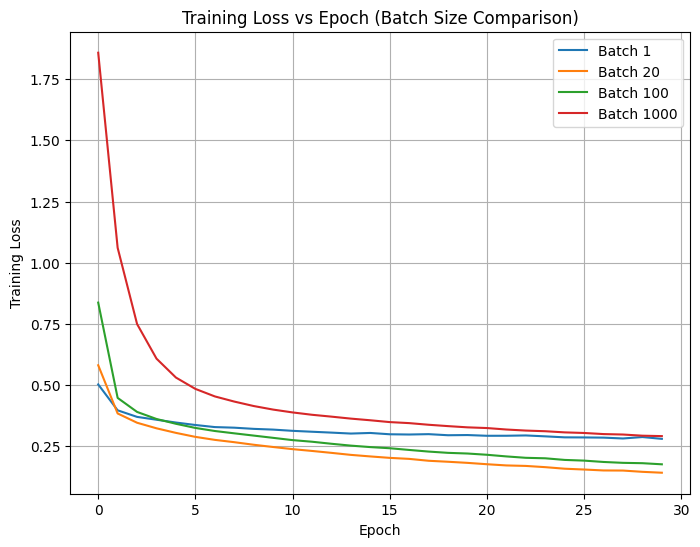

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_bs1.history['loss'], label='Batch 1')
plt.plot(history_bs20.history['loss'], label='Batch 20')
plt.plot(history_bs100.history['loss'], label='Batch 100')
plt.plot(history_bs1000.history['loss'], label='Batch 1000')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch (Batch Size Comparison)")
plt.legend()
plt.grid(True)
plt.show()

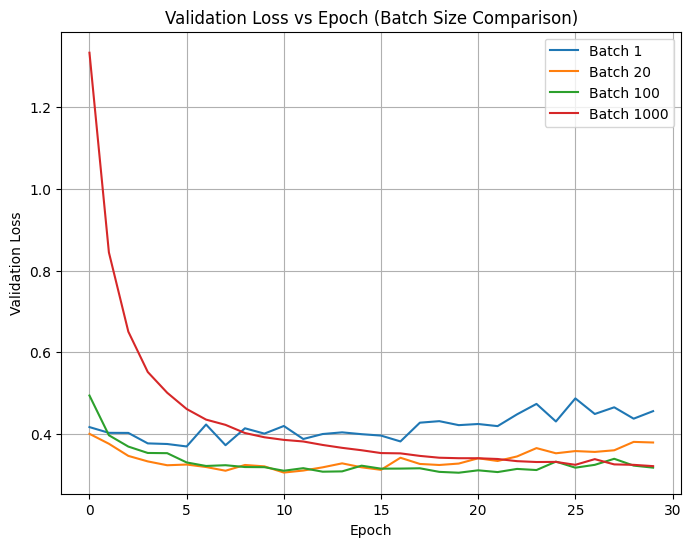

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_bs1.history['val_loss'], label='Batch 1')
plt.plot(history_bs20.history['val_loss'], label='Batch 20')
plt.plot(history_bs100.history['val_loss'], label='Batch 100')
plt.plot(history_bs1000.history['val_loss'], label='Batch 1000')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch (Batch Size Comparison)")
plt.legend()
plt.grid(True)
plt.show()